<a href="https://colab.research.google.com/github/saumyaranjansatpathy731-oss/Car_Price_Prediction/blob/main/CAR_PRICE_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CAR PRICE PREDICTION WITH THE HELP OF A MACHINE LEARNING MODEL**

NAME : SAUMYA RANJAN SATAPATHY

BATCH : P1

OASIS INFOBYTE@DATASCIENCE INTERNSHIP

TASK 3:
PROJECT ON: The price of a car depends on a lot of factors like the good will of the brand of the car, features of the car, horsepower and the mileage it gives and many more. Car price prediction is one of the major research areas in machine learning. So train a price prediction model for the above requirement.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('car data.csv')

print("Dataset Head:")
print(df.head())

print("\nDataset Info:")
print(df.info())

Dataset Head:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    

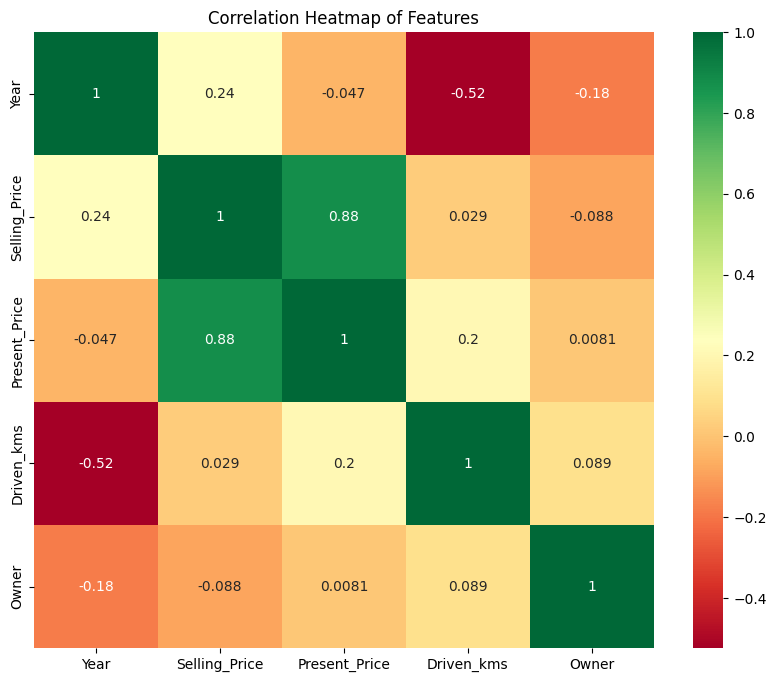

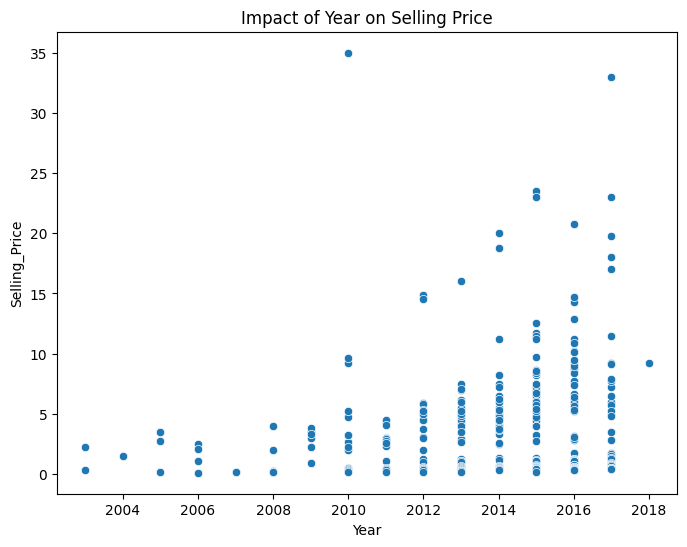

In [ ]:

plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation Heatmap of Features')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Year', y='Selling_Price')
plt.title('Impact of Year on Selling Price')
plt.show()

In [ ]:

current_year = 2024
df['Age'] = current_year - df['Year']

df_final = df.drop(['Car_Name', 'Year'], axis=1)

df_final = pd.get_dummies(df_final, drop_first=True)

print("Data after Preprocessing:")
print(df_final.head())

Data after Preprocessing:
   Selling_Price  Present_Price  Driven_kms  Owner  Age  Fuel_Type_Diesel  \
0           3.35           5.59       27000      0   10             False   
1           4.75           9.54       43000      0   11              True   
2           7.25           9.85        6900      0    7             False   
3           2.85           4.15        5200      0   13             False   
4           4.60           6.87       42450      0   10              True   

   Fuel_Type_Petrol  Selling_type_Individual  Transmission_Manual  
0              True                    False                 True  
1             False                    False                 True  
2              True                    False                 True  
3              True                    False                 True  
4             False                    False                 True  


In [ ]:
from sklearn.model_selection import train_test_split

X = df_final.drop('Selling_Price', axis=1)
y = df_final['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 240
Testing samples: 61


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

predictions = rf_model.predict(X_test)

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"R-squared Score: {r2:.4f} (Closer to 1.0 is better)")
print(f"Mean Absolute Error: {mae:.2f} Lakhs")

R-squared Score: 0.9595 (Closer to 1.0 is better)
Mean Absolute Error: 0.64 Lakhs


/tmp/ipykernel_5462/3939993876.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


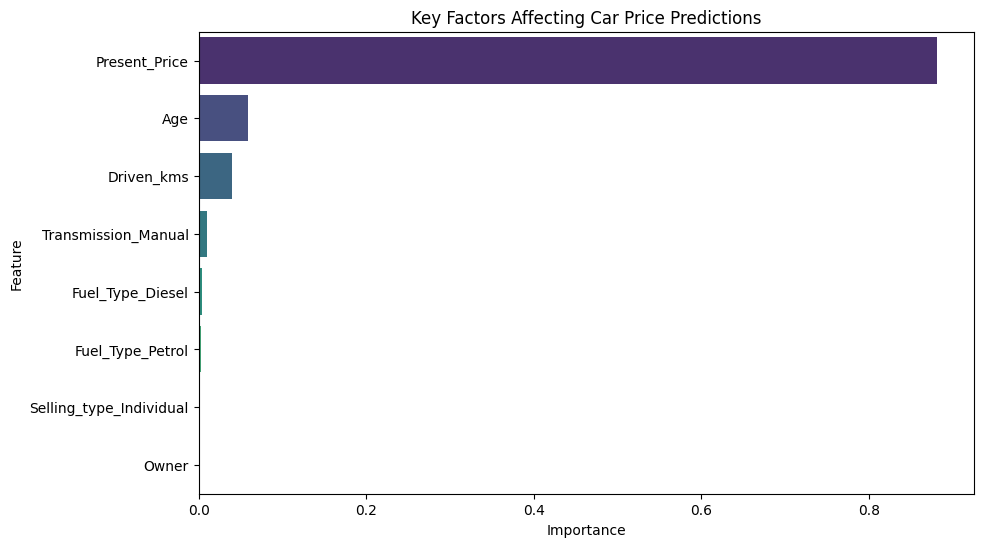

In [ ]:

importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Key Factors Affecting Car Price Predictions')
plt.show()

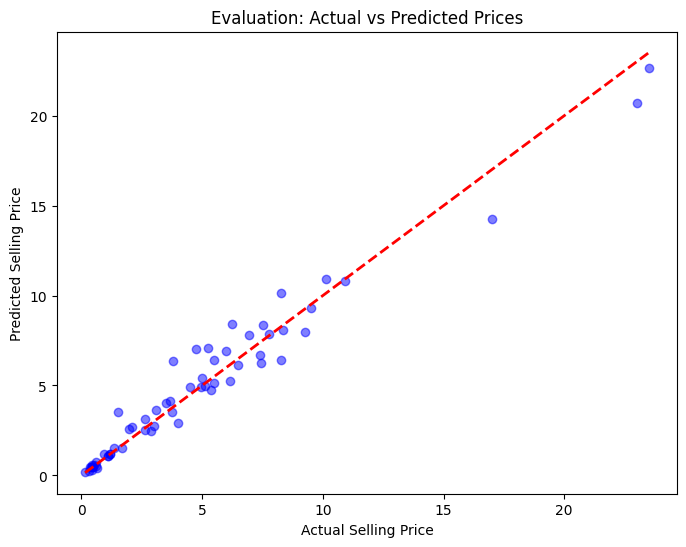


************************************************************
DONE!!..
************************************************************


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Evaluation: Actual vs Predicted Prices')
plt.show()


print("\n" + "*"*60)
print("DONE!!..")
print("*"*60)